## Étape 3 — Charger et explorer les données

In [2]:
# ==============================
# PROJET CIE — Analyse de consommation électrique
# Étape 1 : Chargement des données
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataset
df = pd.read_csv(
    'data/household_power_consumption.txt',
    sep=';',
    na_values='?',
    low_memory=False
)

# Afficher les 5 premières lignes
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
# ==============================
# Étape 2 : Exploration des données
# ==============================

# Nombre de lignes et colonnes
print("Dimensions du dataset :")
print(df.shape)

print("\n Types de chaque colonne :")
print(df.dtypes)

print("\n Valeurs manquantes par colonne :")
print(df.isnull().sum())

print("\n Statistiques générales :")
df.describe()

Dimensions du dataset :
(2075259, 9)

 Types de chaque colonne :
Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

 Valeurs manquantes par colonne :
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

 Statistiques générales :


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [4]:
# ==============================
# Étape 3 : Nettoyage des données
# ==============================

# 1. Fusionner Date et Time en une seule colonne datetime
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'], 
    format='%d/%m/%Y %H:%M:%S'
)

In [5]:
# 2. Supprimer les anciennes colonnes Date et Time
df.drop(columns=['Date', 'Time'], inplace=True)

In [6]:
# 3. Mettre Datetime en index
df.set_index('Datetime', inplace=True)

In [7]:
# 4. Supprimer les lignes avec valeurs manquantes
df.dropna(inplace=True)

In [8]:
# 5. Vérification
print("Dimensions après nettoyage :", df.shape)
print("\n Valeurs manquantes restantes :")
print(df.isnull().sum())
print("\n Aperçu du dataset nettoyé :")
df.head()

Dimensions après nettoyage : (2049280, 7)

 Valeurs manquantes restantes :
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

 Aperçu du dataset nettoyé :


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [9]:
# ==============================
# Étape 4 : Analyse Univariée
# Global_active_power (consommation en kW)
# ==============================

print("STATISTIQUES DE LA CONSOMMATION ÉLECTRIQUE")
print("=" * 50)
print(f"Moyenne     : {df['Global_active_power'].mean():.3f} kW")
print(f"Médiane     : {df['Global_active_power'].median():.3f} kW")
print(f"Écart-type  : {df['Global_active_power'].std():.3f} kW")
print(f"Minimum     : {df['Global_active_power'].min():.3f} kW")
print(f"Maximum     : {df['Global_active_power'].max():.3f} kW")
print(f"25%         : {df['Global_active_power'].quantile(0.25):.3f} kW")
print(f"75%         : {df['Global_active_power'].quantile(0.75):.3f} kW")

STATISTIQUES DE LA CONSOMMATION ÉLECTRIQUE
Moyenne     : 1.092 kW
Médiane     : 0.602 kW
Écart-type  : 1.057 kW
Minimum     : 0.076 kW
Maximum     : 11.122 kW
25%         : 0.308 kW
75%         : 1.528 kW


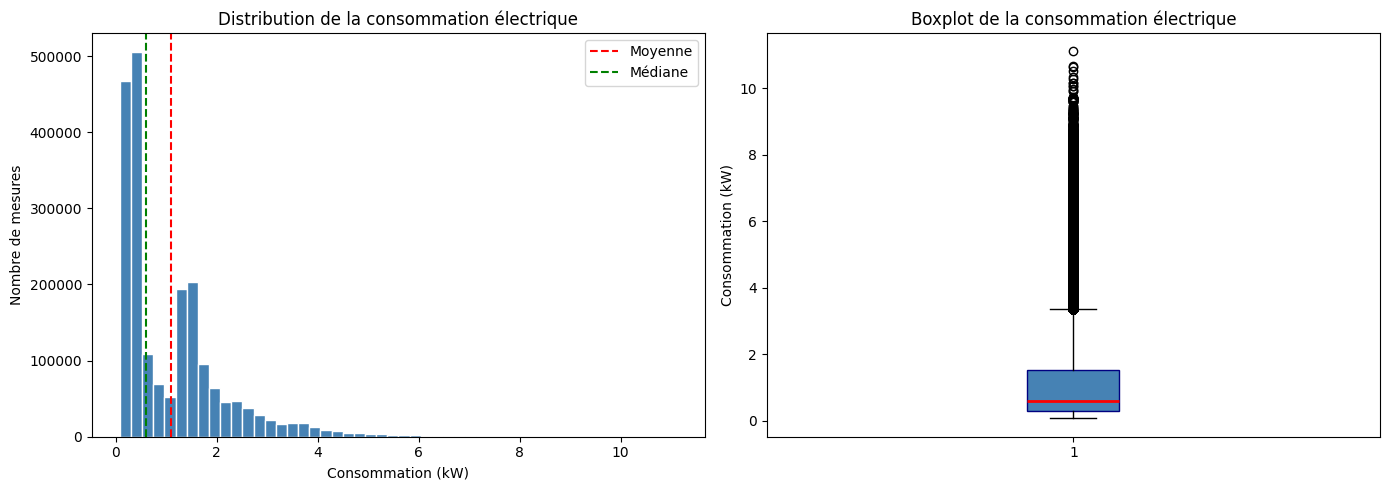

In [10]:
# ==============================
# Visualisation Univariée
# ==============================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogramme ---
axes[0].hist(
    df['Global_active_power'],
    bins=50,
    color='steelblue',
    edgecolor='white'
)
axes[0].set_title('Distribution de la consommation électrique')
axes[0].set_xlabel('Consommation (kW)')
axes[0].set_ylabel('Nombre de mesures')
axes[0].axvline(
    df['Global_active_power'].mean(),
    color='red', linestyle='--', label='Moyenne'
)
axes[0].axvline(
    df['Global_active_power'].median(),
    color='green', linestyle='--', label='Médiane'
)
axes[0].legend()

# --- Boxplot ---
axes[1].boxplot(
    df['Global_active_power'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', color='navy'),
    medianprops=dict(color='red', linewidth=2)
)
axes[1].set_title('Boxplot de la consommation électrique')
axes[1].set_ylabel('Consommation (kW)')

plt.tight_layout()
plt.savefig('outputs/univarie_consommation.png', dpi=150)
plt.show()

In [11]:
# ==============================
# Étape 5 : Analyse Bivariée
# ==============================

# Extraire le mois, l'heure et le jour de la semaine
df['mois'] = df.index.month
df['heure'] = df.index.hour
df['jour_semaine'] = df.index.dayofweek

print("Nouvelles colonnes ajoutées :")
df[['mois', 'heure', 'jour_semaine']].head(10)

Nouvelles colonnes ajoutées :


,mois,heure,jour_semaine
Datetime,,,
2006-12-16 17:24:00,12,17,5
2006-12-16 17:25:00,12,17,5
2006-12-16 17:26:00,12,17,5
2006-12-16 17:27:00,12,17,5
2006-12-16 17:28:00,12,17,5
2006-12-16 17:29:00,12,17,5
2006-12-16 17:30:00,12,17,5
2006-12-16 17:31:00,12,17,5
2006-12-16 17:32:00,12,17,5


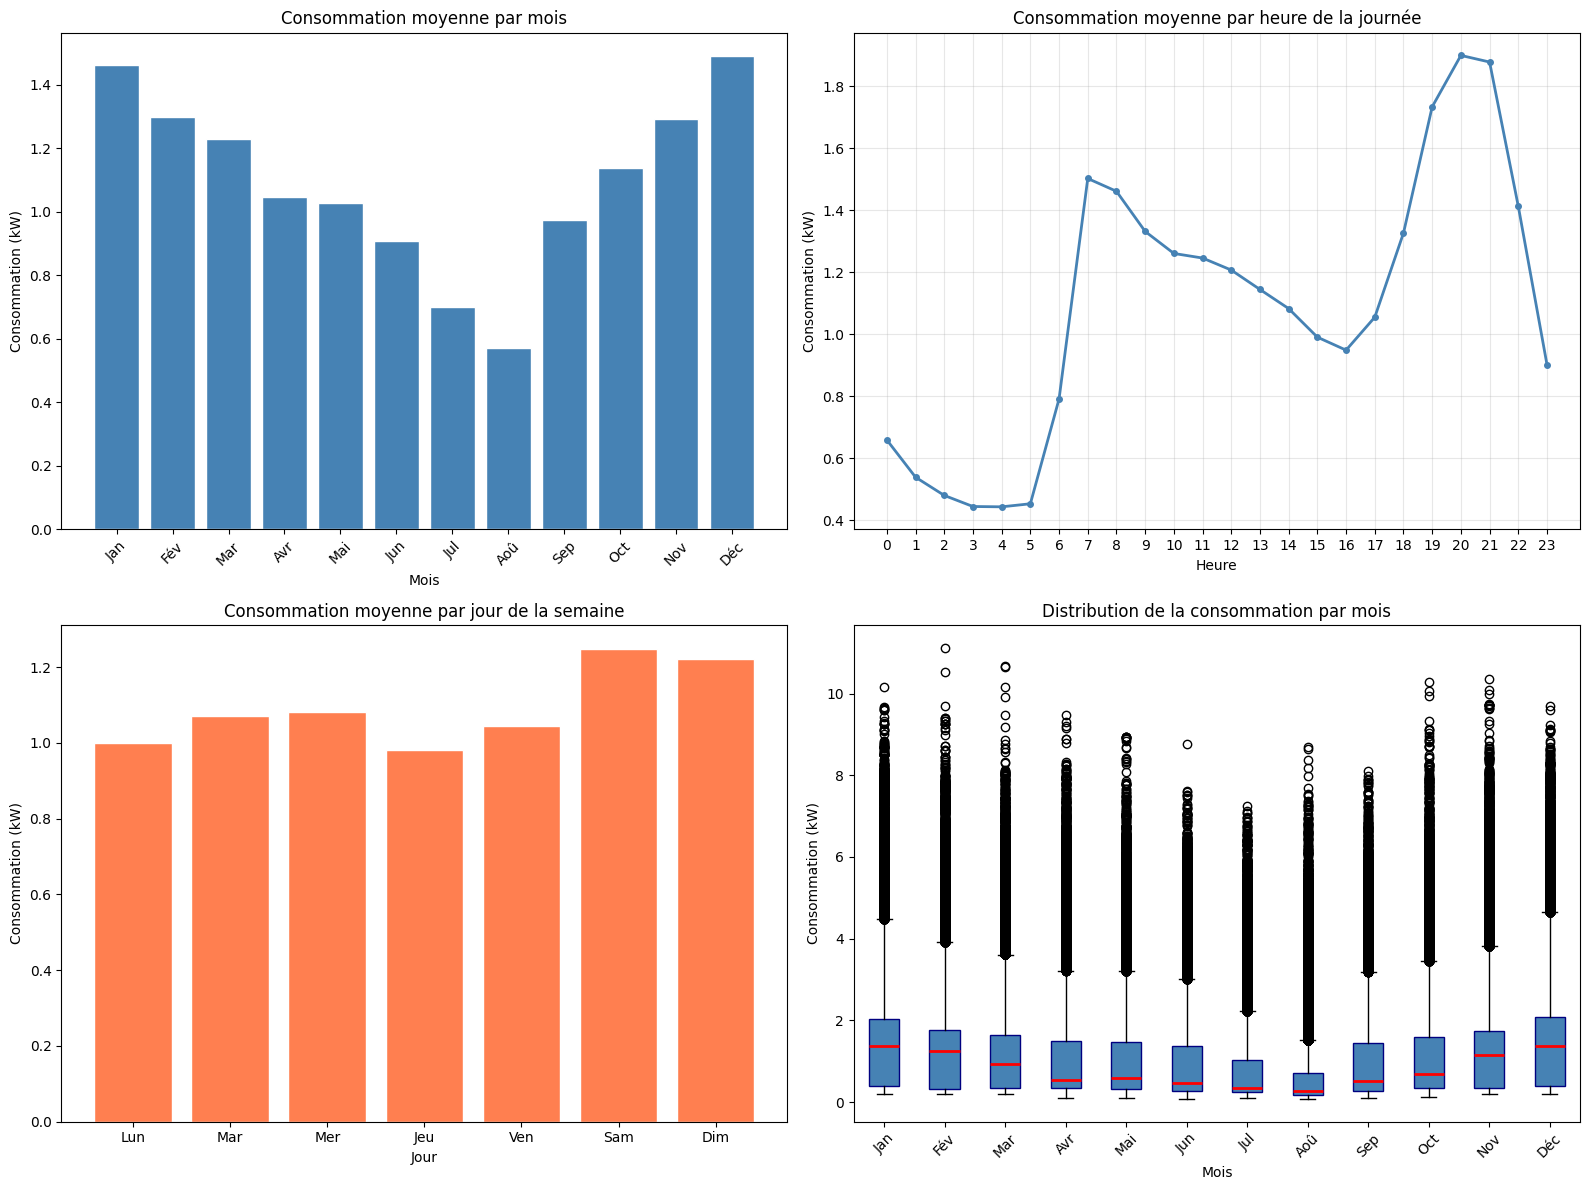

In [13]:
# ==============================
# Visualisation Bivariée
# ==============================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Graphique 1 : Consommation moyenne par mois ---
conso_mois = df.groupby('mois')['Global_active_power'].mean()
noms_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
             'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
axes[0, 0].bar(noms_mois, conso_mois.values, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Consommation moyenne par mois')
axes[0, 0].set_xlabel('Mois')
axes[0, 0].set_ylabel('Consommation (kW)')
axes[0, 0].tick_params(axis='x', rotation=45)

# --- Graphique 2 : Consommation moyenne par heure ---
conso_heure = df.groupby('heure')['Global_active_power'].mean()
axes[0, 1].plot(conso_heure.index, conso_heure.values,
                color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0, 1].set_title('Consommation moyenne par heure de la journée')
axes[0, 1].set_xlabel('Heure')
axes[0, 1].set_ylabel('Consommation (kW)')
axes[0, 1].set_xticks(range(0, 24))
axes[0, 1].grid(True, alpha=0.3)

# --- Graphique 3 : Consommation par jour de la semaine ---
conso_jour = df.groupby('jour_semaine')['Global_active_power'].mean()
noms_jours = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
axes[1, 0].bar(noms_jours, conso_jour.values, color='coral', edgecolor='white')
axes[1, 0].set_title('Consommation moyenne par jour de la semaine')
axes[1, 0].set_xlabel('Jour')
axes[1, 0].set_ylabel('Consommation (kW)')

# --- Graphique 4 : Boxplot consommation par mois ---
data_par_mois = [df[df['mois'] == m]['Global_active_power'].values
                 for m in range(1, 13)]
axes[1, 1].boxplot(data_par_mois, tick_labels=noms_mois, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', color='navy'),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_title('Distribution de la consommation par mois')
axes[1, 1].set_xlabel('Mois')
axes[1, 1].set_ylabel('Consommation (kW)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/bivarie_consommation.png', dpi=150)
plt.show()

In [15]:
# ==============================
# Étape 6 : Conclusions
# ==============================

print("""
╔══════════════════════════════════════════════════════════════╗
║         CONCLUSIONS — ANALYSE DE CONSOMMATION ÉLECTRIQUE     ║
╚══════════════════════════════════════════════════════════════╝

📊 STATISTIQUES CLÉS
─────────────────────
- Consommation moyenne  : 1.092 kW
- Consommation médiane  : 0.602 kW
- Pic maximum détecté   : 11.122 kW
- Données analysées     : 2 049 280 mesures sur 4 ans

🔍 ANALYSE UNIVARIÉE
─────────────────────
- La distribution est asymétrique à droite
- La majorité des mesures se concentrent entre 0.3 et 1.5 kW
- Des outliers (pics anormaux) ont été détectés au-delà de 3.5 kW

📅 ANALYSE BIVARIÉE — PAR MOIS
────────────────────────────────
- Pic hivernal     : Décembre et Janvier (~1.45 kW)
- Creux estival    : Juillet et Août (~0.6 kW)
- Variation        : La consommation double entre l'été et l'hiver

⏰ ANALYSE BIVARIÉE — PAR HEURE
─────────────────────────────────
- Creux nocturne   : 0h-5h (~0.4 kW) — période de sommeil
- Pic matinal      : 7h (~1.5 kW) — réveil et petit-déjeuner
- Pic du soir      : 20h-21h (~1.9 kW) — retour à domicile
- Ces 2 pics sont critiques pour la gestion du réseau électrique

📆 ANALYSE BIVARIÉE — PAR JOUR
────────────────────────────────
- Semaine          : Consommation stable (~1.0 kW)
- Week-end         : Consommation plus élevée (~1.25 kW)
- Raison           : Présence à domicile plus importante

💡 RECOMMANDATIONS POUR LA CIE
────────────────────────────────
1. Renforcer le réseau aux heures de pointe (20h-21h)
2. Anticiper les pics saisonniers selon le contexte ivoirien
3. Surveiller les outliers comme indicateurs de fraude possible
4. Proposer des tarifs réduits la nuit pour lisser la demande
""")


╔══════════════════════════════════════════════════════════════╗
║         CONCLUSIONS — ANALYSE DE CONSOMMATION ÉLECTRIQUE     ║
╚══════════════════════════════════════════════════════════════╝

📊 STATISTIQUES CLÉS
─────────────────────
- Consommation moyenne  : 1.092 kW
- Consommation médiane  : 0.602 kW
- Pic maximum détecté   : 11.122 kW
- Données analysées     : 2 049 280 mesures sur 4 ans

🔍 ANALYSE UNIVARIÉE
─────────────────────
- La distribution est asymétrique à droite
- La majorité des mesures se concentrent entre 0.3 et 1.5 kW
- Des outliers (pics anormaux) ont été détectés au-delà de 3.5 kW

📅 ANALYSE BIVARIÉE — PAR MOIS
────────────────────────────────
- Pic hivernal     : Décembre et Janvier (~1.45 kW)
- Creux estival    : Juillet et Août (~0.6 kW)
- Variation        : La consommation double entre l'été et l'hiver

⏰ ANALYSE BIVARIÉE — PAR HEURE
─────────────────────────────────
- Creux nocturne   : 0h-5h (~0.4 kW) — période de sommeil
- Pic matinal      : 7h (~1.5 kW) 